#Car Price Prediction Using ElasticNet

In [1]:
# Imports Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:
# Load Dataset
df1 = pd.read_csv("car_price_dataset_medium.csv")

In [5]:
# Feature and Target
x = df1.drop(["Car_ID", "Price_USD"], axis=1)
y = df1["Price_USD"]

In [6]:
# Train Test Split
num_cols = ['Model_Year','Kilometers_Driven','Engine_CC','Max_Power_bhp','Mileage_kmpl','Seats']
cat_cols = ['Brand','Fuel_Type','Transmission','Owner_Type']

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
# Pipeline
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("elastic", ElasticNet(max_iter=100000))
])

In [8]:
# GridSearchCV
param_grid = {
    "elastic__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 0.05, 0.1],
    "elastic__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(xtrain, ytrain)

model = grid.best_estimator_

In [9]:
# Prediction + Evaluation
ypred = model.predict(xtest)

print("R2 Score:", r2_score(ytest, ypred))
print("MAE:", mean_absolute_error(ytest, ypred))
print("RMSE:", np.sqrt(mean_squared_error(ytest, ypred)))

R2 Score: 0.0005897781197387042
MAE: 29090.888090126744
RMSE: 33409.887965250986


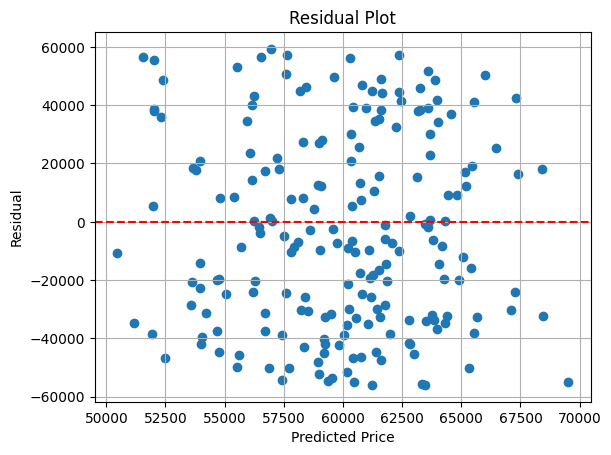

In [10]:
# Residual Plot
residual = ytest - ypred

plt.scatter(ypred, residual)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid()
plt.show()

#Conclusion:

##    * ElasticNet performed better than Linear Regression.

##    * Residual plot shows no strong nonlinear pattern.